setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
import shap
import warnings
import math

warnings.filterwarnings("ignore")

rs = 42
np.random.seed(rs)
df = pd.read_excel("ready_for_modeling_1.xlsx")
for x in ['religionAffiliation', 
          'specialDemographic', 
          'mergingInstitutionPopulation', 
          'mergingInstitutionType', 
          'mergingInstitutionLocationType', 
          'mergingInstitutionReligiousAffiliation',]:
    df[x] = df[x].fillna('None')
df['endowmentMedian'] = df['endowmentMedian'].fillna(-1)
df.drop(columns=['mergingInstitutionPopulation'], inplace=True)

colors_tab20 = cm['tab20'].resampled(20).colors
colors_tab20b = cm['tab20b'].resampled(20).colors
tab_colors = list(colors_tab20) + list(colors_tab20b)

df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateFourYearAppropriationsPerFTEMedian,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,5634.822870,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,14514.215742,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,6263.361828,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,12392.121586,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,10431.614347,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329


combining reason of closures into a single feature

In [ ]:
df.loc[df['name'].isin(['Independence University', 'Alliance University (Formerly Nyack College)']), 'reasonFinancial'] = True

reason_cols = ['reasonFinancial', 'reasonEnrollment', 'reasonPandemic', 'reasonMutualBenefit']
def create_reason_closure(row):
    reasons = [str(i) for i, reason in enumerate(reason_cols) if row[reason]]
    return ''.join(sorted(reasons)) if reasons else 'None'

df['reasonClosure'] = df.apply(create_reason_closure, axis=1)
df.to_csv('full_data.csv', index=False)
df

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian,reasonClosure
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075,0
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501,0
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797,3
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585,12
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,1900,Massachusetts,MA,Suburb,Large,Private,Nonprofit,4-year,True,...,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585,0
61,Cox College,1907,Missouri,MO,City,Midsize,Private,Nonprofit,4-year,True,...,3158.651054,8110.752686,318494.5,2520719.5,185163.0,1276294.0,318494.5,2520719.5,59202,0
62,University of Wisconsin–Platteville Richland,1967,Wisconsin,WI,Town,Distant,Public,Nonprofit,4-year,True,...,2499.698379,9046.426414,313717.5,2507124.5,179977.5,1210502.5,313717.5,2507124.5,62713,1
63,Maryland University of Integrative Health,1974,Maryland,MD,Suburb,Large,Private,Nonprofit,graduate school,False,...,4758.870615,11787.159727,306338.5,2800406.0,166310.5,1014233.5,306338.5,2800406.0,71897,3


splitting

In [3]:
labels = df[['name', 'reasonClosure']].copy()
label_cols = ['name', 'reasonClosure', 'state', 'stateAbbreviation', 'region']
lessImpact_cols = ['yearClosed', 'yearEstablished', 'typeProfit', 'religionAffiliation',
                  'specialDemographic', 'mergingInstitutionType',
                  'mergingInstitutionLocationType', 'mergingInstitutionReligiousAffiliation',
                  'stateBirths', 'stateFemalePopulation', 'regionFemalePopulation', 'regionBirths']
X_df = df.drop(columns=label_cols + lessImpact_cols + reason_cols)
X_df.head()

,locationType,locationTypeKind,typeOwned,level,hasUndergraduate,hasGraduate,totalEnrollment,hasReligionAffiliation,hasSpecialDemographic,carnegieAward,...,stateFourYearAppropriationsPerFTEMedian,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian
0,Rural,Distant,Private,4-year,True,True,767,True,False,Baccalaureate Colleges,...,5634.822870,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075
1,City,Large,Private,4-year,True,True,2479,True,False,Master's Colleges & Universities,...,14514.215742,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501
2,Rural,Distant,Private,2-year,True,False,469,True,False,Associate's Colleges,...,6263.361828,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797
3,City,Midsize,Private,4-year,True,True,1973,False,False,Baccalaureate Colleges,...,12392.121586,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585
4,Suburb,Large,Private,4-year,True,True,1737,True,False,Baccalaureate Colleges,...,10431.614347,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329


scale and encoding

In [4]:
cat_cols = X_df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X = preprocessor.fit_transform(X_df)

cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])
X_processed = pd.DataFrame(X, columns=feature_names)
X_processed.head()

,totalEnrollment,statePopulation,stateBirthRate,stateFertilityRate,statePercentOfTotalBirths,regionPopulation,regionBirthRate,regionFertilityRate,regionPercentOfTotalBirths,stateUnemploymentRate,...,carnegieProgram_Larger Programs,carnegieProgram_Medium Programs,carnegieProgram_Mixed Baccalaureate/Associate's,carnegieProgram_Mixed Baccalaureate/Associates,carnegieProgram_Mixed Transfer/Career & Technical-High Traditional,carnegieProgram_Other Health Professions Schools,carnegieProgram_Small Programs,carnegieProgram_Very High Research Activity,isMerged_FALSE,isMerged_TRUE
0,-0.248250,-0.985942,-1.191379,-0.135674,-0.991863,2.012311,1.433407,1.070530,2.005135,-0.391768,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.200285,0.696062,0.084361,-0.211953,0.693904,-0.865960,-1.471940,-1.253219,-0.905581,0.105109,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.326324,-0.513536,1.091523,1.141382,-0.453178,-0.374643,0.356425,0.725906,-0.328781,-0.267549,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.067715,-0.498150,-1.101853,-1.781822,-0.554577,-0.865960,-1.471940,-1.253219,-0.905581,0.601985,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.005885,-0.295810,0.308175,0.693551,-0.272560,-0.865960,-1.471940,-1.253219,-0.905581,0.850424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
X_processed.shape

(65, 66)

finding the number of clusters

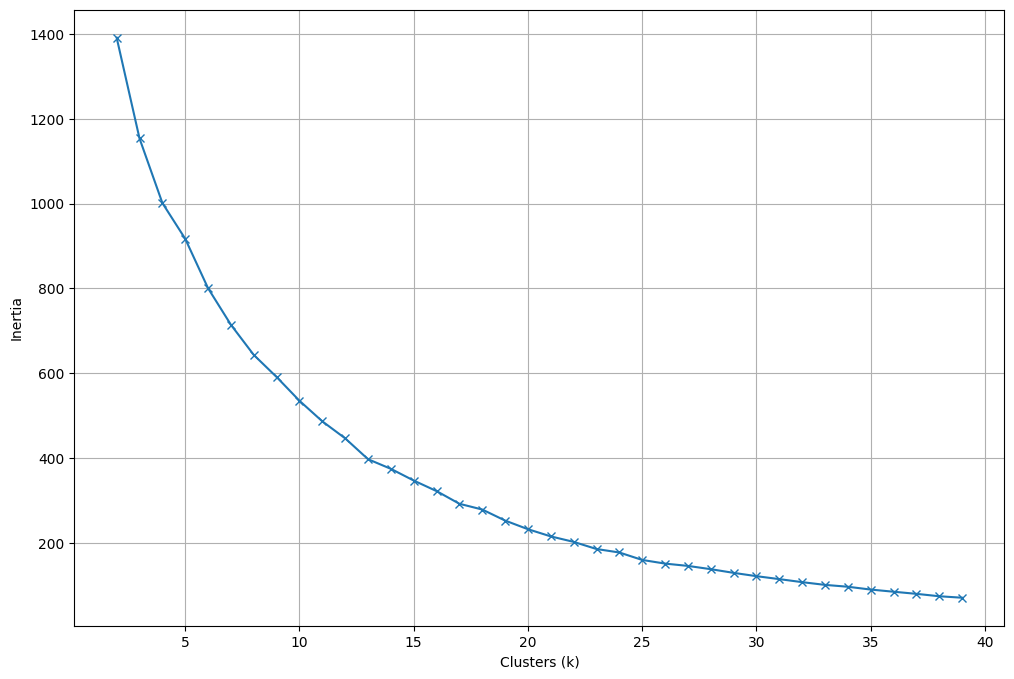

In [6]:
inertia = []
k_range = range(2, 40)
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=rs)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(k_range, inertia, marker='x', color='tab:blue')
plt.xlabel('Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

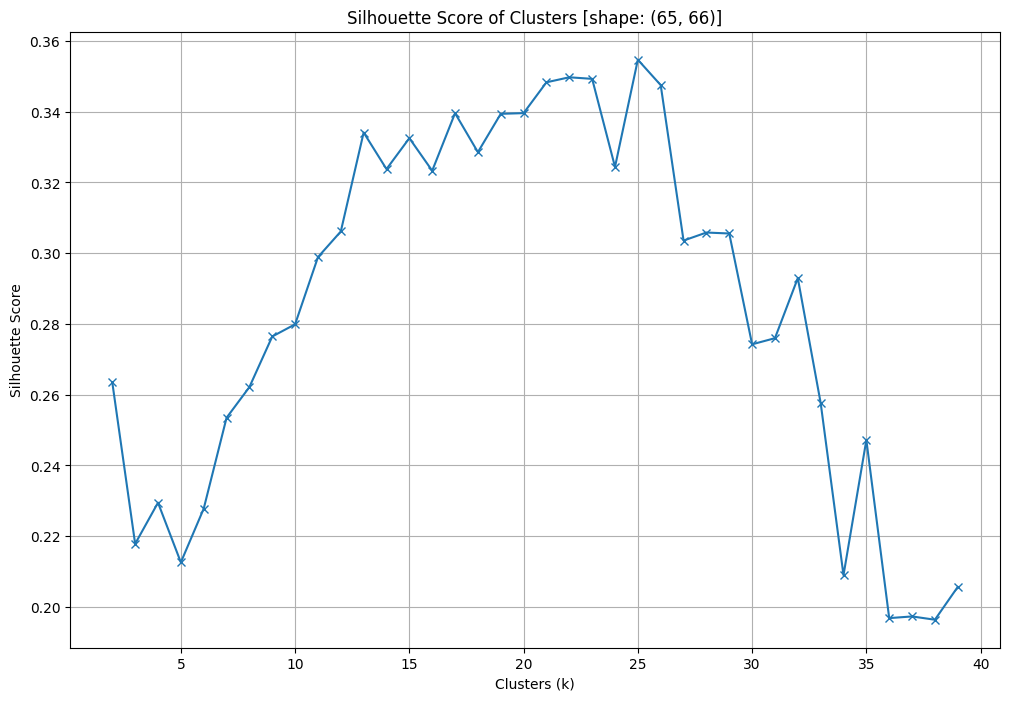

Top 5 optimal-k candidates:
k = 25 (0.3547)
k = 22 (0.3497)
k = 23 (0.3493)
k = 21 (0.3483)
k = 26 (0.3475)


In [7]:
silhouettes = []
for k in range(2, 40):
    kmeans = KMeans(n_clusters=k, random_state=rs, n_init=10)
    kmeans.fit(X)
    silhouettes.append(metrics.silhouette_score(X, kmeans.labels_))

plt.figure(figsize=(12, 8))
plt.plot(k_range, silhouettes, marker='x', color='tab:blue')
plt.xlabel('Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score of Clusters [shape: (65, 66)]')
plt.grid()
plt.show()

print("Top 5 optimal-k candidates:")
for idx in np.argsort(silhouettes)[-5:][::-1]:
    print(f"k = {k_range[idx]} ({silhouettes[idx]:.4f})")

k-means clustering

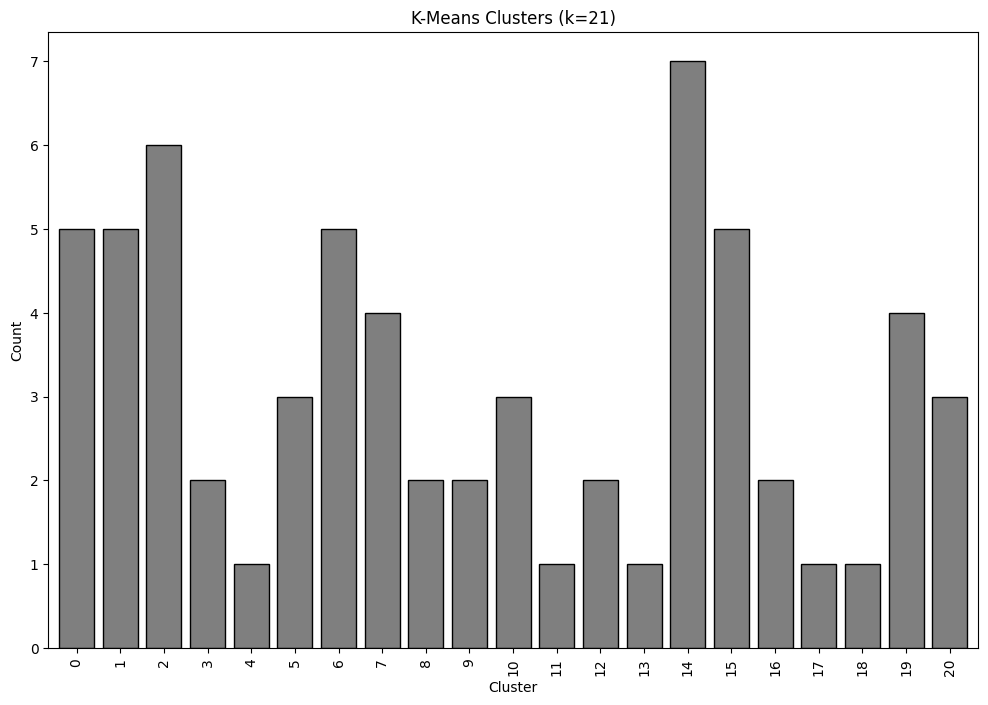

In [8]:
optimal_k = 21
kmeans = KMeans(n_clusters=optimal_k, random_state=rs)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(12, 8))
labels['kmeans_cluster'] = kmeans_labels
labels['kmeans_cluster'].value_counts().sort_index().plot(kind='bar', color='tab:gray', edgecolor='black', width=0.8)
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title(f'K-Means Clusters (k={optimal_k})')
plt.show()

PCA

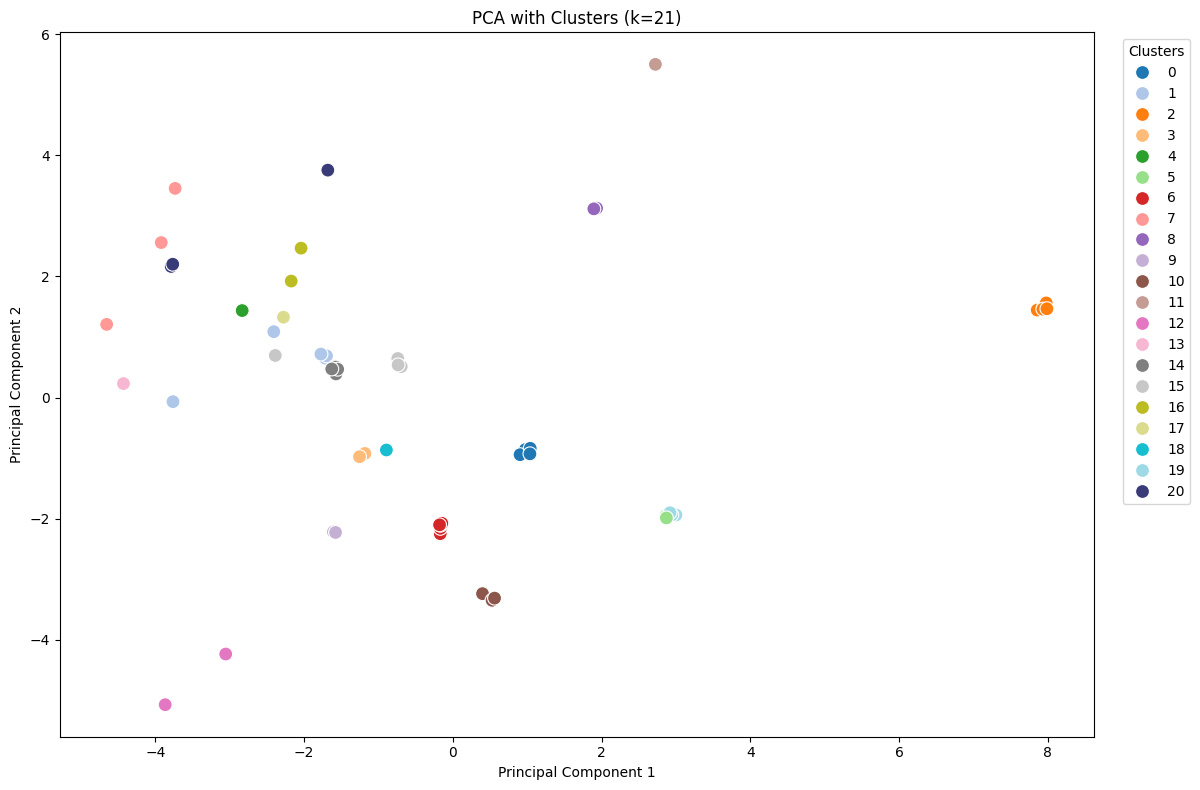


Eigenvalues: 
[10.70836027  4.29049788  2.33301619  2.13733413  1.63856983  1.37227665
  1.21392104  0.92500343  0.77880221  0.53811022]

Explained Variance Ratio: 
[0.36626936 0.14675243 0.07979862 0.0731055  0.05604574 0.04693743
 0.04152102 0.03163887 0.0266382  0.01840555]

Number of PCs for 95% variance: 17

Variance explained by top 5 PCs: 72.20%


In [9]:
pca = PCA(random_state=rs)
X_pca = pca.fit_transform(X)

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

for i in range(5):
    labels[f'pca_component_{i+1}'] = X_pca[:, i]

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette=tab_colors, s=100)
# for i, name in enumerate(labels['name']):
#     plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA with Clusters (k=21)')
plt.legend(title='Clusters', loc='upper right', bbox_to_anchor=(1.1, 1))
plt.tight_layout()
plt.show()

print(f"\nEigenvalues: \n{eigenvalues[:10]}")
print(f"\nExplained Variance Ratio: \n{explained_variance_ratio[:10]}")
print(f"\nNumber of PCs for 95% variance: {n_components_95}")
print(f"\nVariance explained by top 5 PCs: {cumulative_variance[4]*100:.2f}%")

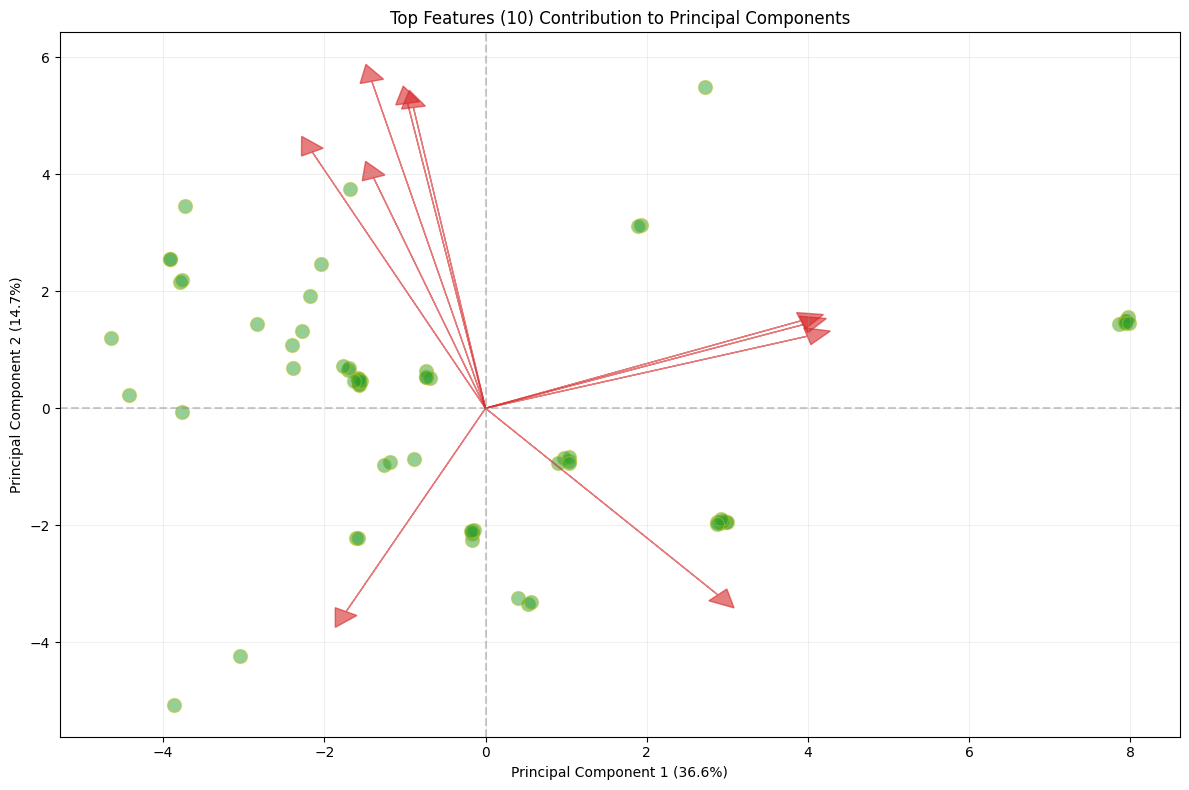

In [10]:
plt.figure(figsize=(12, 8))
component_loadings = pca.components_.T

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c='tab:green', alpha=0.5, s=100, edgecolor='tab:olive')

scaling = np.max(np.abs(X_pca[:, :2])) / np.max(np.abs(component_loadings[:, :2])) * 0.7

feature_importance = np.sum(np.abs(component_loadings[:, :2]), axis=1)
top_indices = np.argsort(-feature_importance)[:10]  # Top 15 most important features

for i in top_indices:
    name = feature_names[i]
    if len(name) > 25:
        name = name[:22] + "..."
    
    plt.arrow(0, 0, 
              component_loadings[i, 0] * scaling, 
              component_loadings[i, 1] * scaling, 
              color='tab:red', alpha=0.6, 
              head_width=0.3, head_length=0.3)
    
    # # Position text labels to avoid overlap
    # text_x = component_loadings[i, 0] * scaling * 1.15
    # text_y = component_loadings[i, 1] * scaling * 1.15
    
    # plt.text(text_x, text_y, name, 
    #          color='darkred', fontsize=9, fontweight='bold',
    #          ha='center', va='center')

plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('Top Features (10) Contribution to Principal Components')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
plt.grid(alpha=0.2)

# Add some annotations about variance
# plt.annotate(f'Total variance explained: {(cumulative_variance[1])*100:.1f}%', 
#              xy=(0.02, 0.98), xycoords='axes fraction',
#              fontsize=12, fontweight='bold',
#              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

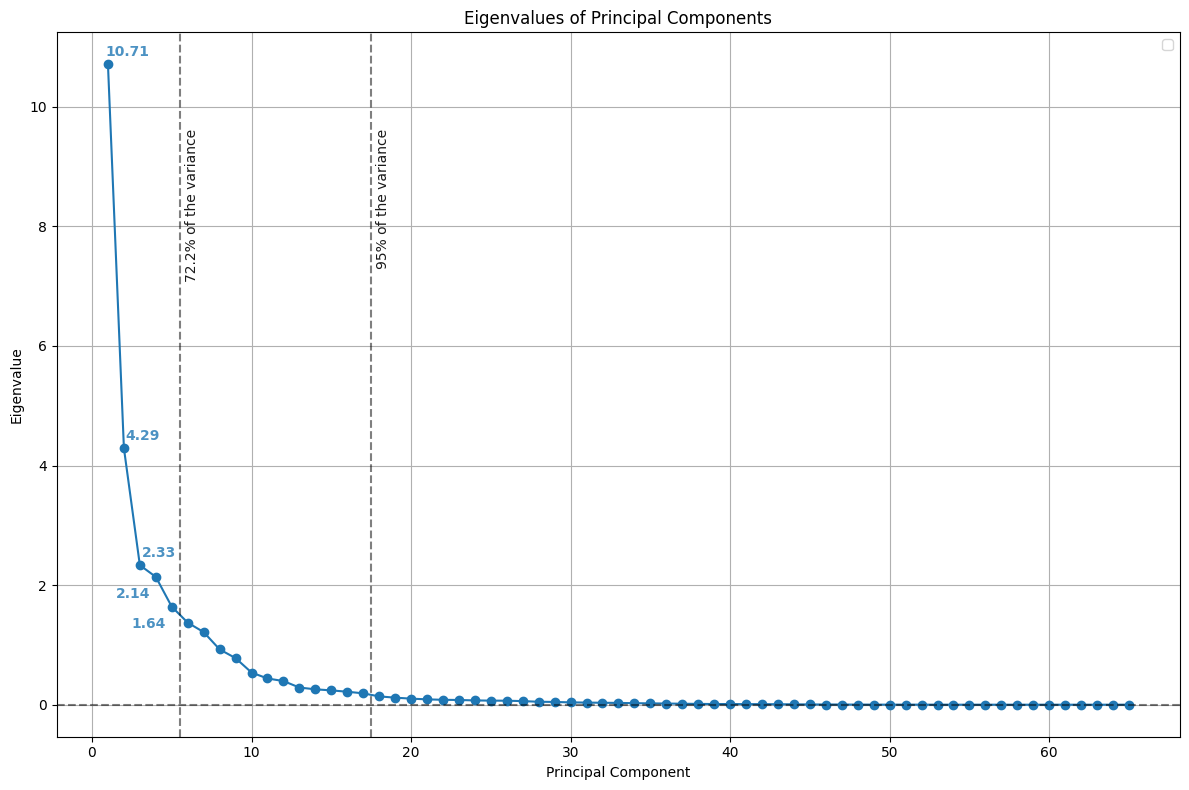

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='tab:blue')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Principal Components')
plt.grid()
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=5.5, color='k', linestyle='--', alpha=0.5)

vline_x_position1 = 5.8
vline_y_position1 = max(eigenvalues) * 0.9

plt.text(vline_x_position1, vline_y_position1, '72.2% of the variance',
         rotation=90,
         verticalalignment='top',
         fontsize=10,
         color='k',
         alpha=0.9)


plt.axvline(x=17.5, color='k', linestyle='--', alpha=0.5)

vline_x_position2 = 17.8
vline_y_position2 = max(eigenvalues) * 0.9

plt.text(vline_x_position2, vline_y_position2, '95% of the variance',
         rotation=90,
         verticalalignment='top',
         fontsize=10,
         color='k',
         alpha=0.9)


x_offset = 1.2
y_offset = 0.2

for i, val in enumerate(eigenvalues[:3]):
    plt.text(i + 1 + x_offset, val + y_offset, f'{val:.2f}',
             fontsize=10,
             fontweight='bold',
             ha='center',
             va='center',
             color='tab:blue',
             alpha=0.8)
x_offset1 = 0.5
y_offset1 = -0.4
for i, val in enumerate(eigenvalues[3:5]):
    plt.text(i + 1 + x_offset1, val + y_offset1, f'{val:.2f}',
             fontsize=10,
             fontweight='bold',
             ha='left',
             va='bottom',
             color='tab:blue',
             alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

T-SNE

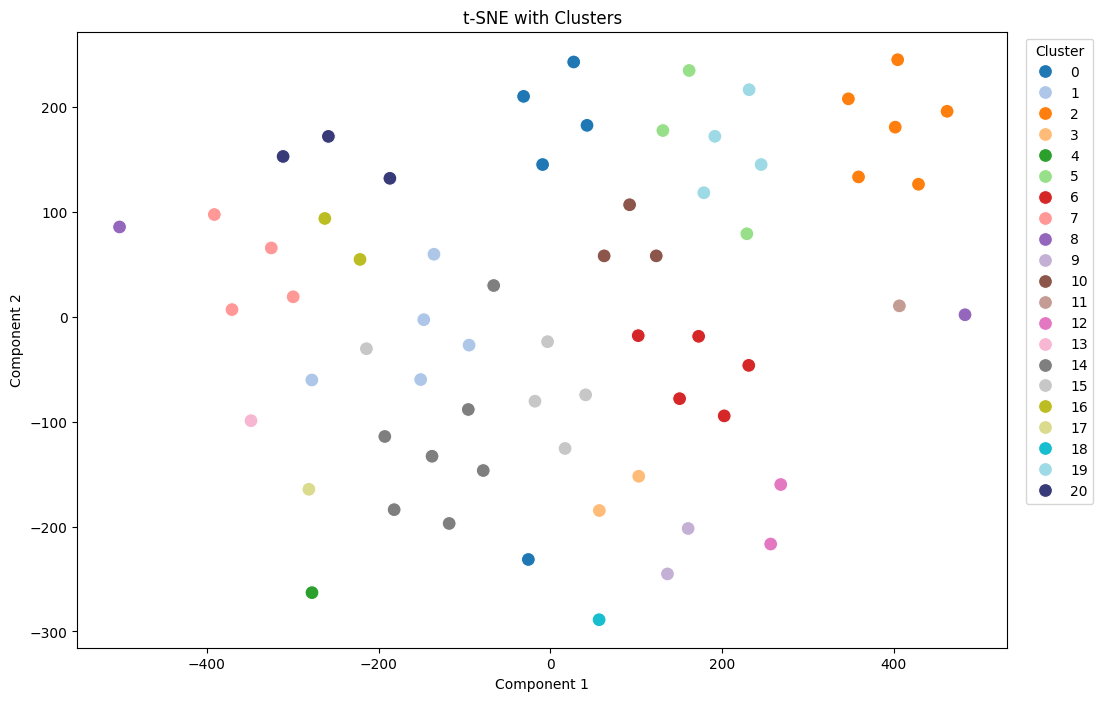

In [12]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X)

labels['tsne_x'] = X_tsne[:, 0]
labels['tsne_y'] = X_tsne[:, 1]

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette=tab_colors, s=100)
# for i, name in enumerate(labels['name']):
#     plt.text(X_tsne[i, 0], X_tsne[i, 1], name, fontsize=8)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('t-SNE with Clusters')
plt.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.1, 1))

plt.show()

LDA

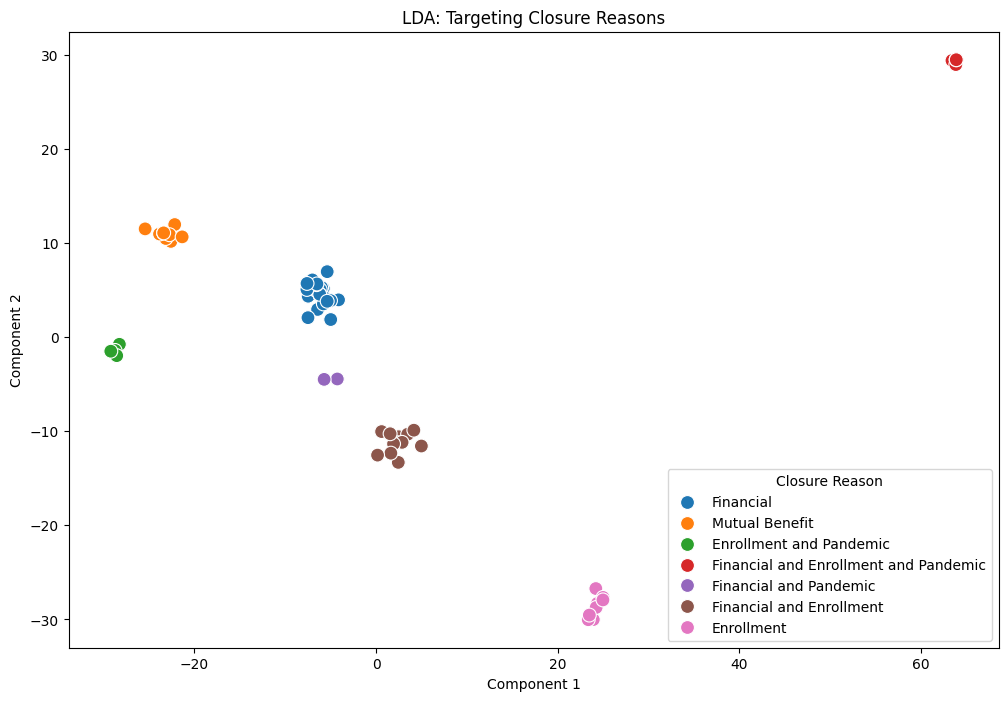


Explained Variance Ratio: 
[0.66338788 0.26486255 0.05043409 0.01010974 0.0092096  0.00199614]

Financial:
['Alderson Broaddus University'
 'Alliance University (Formerly Nyack College)' 'Bloomfield College'
 'Cabrini University' 'Hodges University' 'Independence University'
 'Iowa Wesleyan University' 'Judson College' 'MacMurray College'
 'Mills College' 'Multnomah University' 'Notre Dame College'
 'Ohio Valley University' 'Pine Manor College' 'Presentation College'
 'Presidio Graduate School' 'San Francisco Art Institute'
 'The College of Saint Rose' 'Birmingham-Southern College' 'Wells College'
 'Eastern Nazarene College' 'Cox College']

Financial and Enrollment:
['Finlandia University' 'Fontbonne University' 'Holy Names University'
 'Johnson University Florida' 'Lincoln Christian University'
 'Medaille University' 'Nebraska Christian College'
 'UW Oshkosh - Fond du Lac Campus' 'UW Green Bay - Marinette Campus'
 'UW Milwaukee - Washington Campus' 'Wesley College' 'Woodbury Universi

In [13]:
reason_closure_map = {
    '0': 'Financial',
    '1': 'Enrollment',
    '2': 'Pandemic',
    '3': 'Mutual Benefit',
    '12': 'Enrollment and Pandemic',
    '012': 'Financial and Enrollment and Pandemic',
    '02': 'Financial and Pandemic',
    '01': 'Financial and Enrollment'
}
y_reason = labels['reasonClosure']
if len(np.unique(y_reason)) > 1:
    n_components = min(len(np.unique(y_reason)) - 1, X.shape[1])
    lda_reason = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda_reason = lda_reason.fit_transform(X, y_reason)
    
    for i in range(X_lda_reason.shape[1]):
        labels[f'lda_reason_component_{i+1}'] = X_lda_reason[:, i]
    
    if X_lda_reason.shape[1] >= 2:
        y_reason_mapped = y_reason.map(reason_closure_map)
        plt.figure(figsize=(12, 8))
        sns.scatterplot(x=X_lda_reason[:, 0], y=X_lda_reason[:, 1], hue=y_reason_mapped, palette='tab10', s=100, legend='full')
        # for i, name in enumerate(labels['name']):
        #     plt.text(X_lda_reason[i, 0], X_lda_reason[i, 1], name, fontsize=8)
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.title('LDA: Targeting Closure Reasons')
        plt.legend(title='Closure Reason', loc='lower right')
        plt.show()
    
    print(f"\nExplained Variance Ratio: \n{lda_reason.explained_variance_ratio_}\n")
    for reason in np.unique(y_reason):
        if reason == '0':
            label = 'Financial'
        elif reason == '1':
            label = 'Enrollment'
        elif reason == '2':
            label = 'Pandemic'
        elif reason == '3':
            label = 'Mutual Benefit'
        elif reason == '12':
            label = 'Enrollment and Pandemic'
        elif reason == '012':
            label = 'Financial and Enrollment and Pandemic'
        elif reason == '02':
            label = 'Financial and Pandemic'
        elif reason == '01':
            label = 'Financial and Enrollment'
        print(f"{label}:\n{labels[labels['reasonClosure'] == reason]['name'].values}\n")

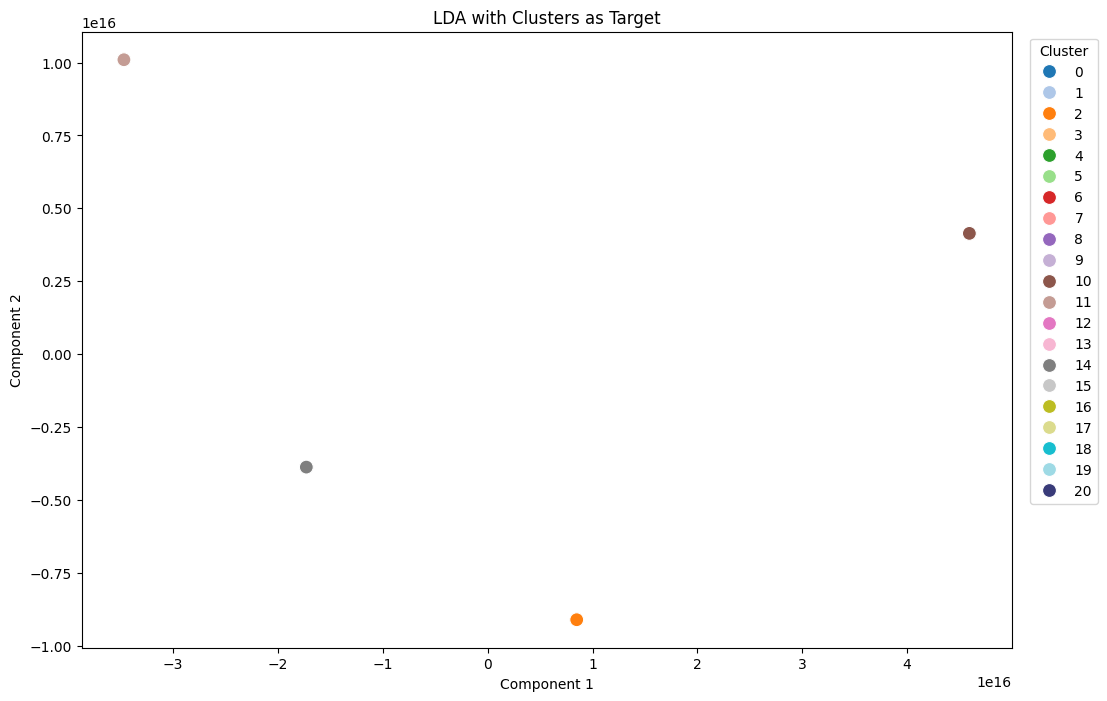


Explained Variance Ratio: 
[9.53890483e-01 4.43137024e-02 1.79581497e-03 3.02922325e-29]


In [14]:
if len(np.unique(kmeans_labels)) > 1:
    lda_kmeans = LinearDiscriminantAnalysis(n_components=min(5-1, X.shape[1]))
    X_lda_kmeans = lda_kmeans.fit_transform(X, kmeans_labels)
    
    for i in range(X_lda_kmeans.shape[1]):
        labels[f'lda_kmeans_component_{i+1}'] = X_lda_kmeans[:, i]

    if X_lda_kmeans.shape[1] >= 2:
        plt.figure(figsize=(12, 8))
        sns.scatterplot(x=X_lda_kmeans[:, 0], y=X_lda_kmeans[:, 1], hue=kmeans_labels, palette=tab_colors, s=100)
        # for i, name in enumerate(labels['name']):
        #     plt.text(X_lda_kmeans[i, 0], X_lda_kmeans[i, 1], name, fontsize=8)
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.title('LDA with Clusters as Target')
        plt.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.1, 1))
        plt.show()
    
        print(f"\nExplained Variance Ratio: \n{lda_kmeans.explained_variance_ratio_}")

summary of clusters

In [15]:
print(f"Cluster Sizes: \n\n{labels['kmeans_cluster'].value_counts(normalize=True)}")

print("\nTop Features per K-Means Cluster (Mean):")
for cluster in range(optimal_k):
    cluster_data = X_processed[labels['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} Top 5 Features:")
    print(cluster_data.mean().sort_values(ascending=True).head(5))

print("\nTop Features per Cluster (by Variance):")
for cluster in range(optimal_k):
    cluster_data = X_processed[labels['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} Top 5 Features by Variance:")
    print(cluster_data.var().sort_values(ascending=False).head(10))

Cluster Sizes: 

kmeans_cluster
14    0.107692
2     0.092308
1     0.076923
15    0.076923
0     0.076923
6     0.076923
7     0.061538
19    0.061538
20    0.046154
5     0.046154
10    0.046154
8     0.030769
3     0.030769
12    0.030769
9     0.030769
16    0.030769
17    0.015385
4     0.015385
13    0.015385
18    0.015385
11    0.015385
Name: proportion, dtype: float64

Top Features per K-Means Cluster (Mean):

Cluster 0 Top 5 Features:
stateFourYearStudentShareMedian   -1.189518
stateFertilityRate                -0.507226
regionPopulation                  -0.374643
regionPercentOfTotalBirths        -0.328781
totalEnrollment                   -0.300229
dtype: float64

Cluster 1 Top 5 Features:
statePopulation25yoAndOverHighSchoolGradMedian        -0.783040
statePerCapitaPersonalIncomeMedian                    -0.746561
statePopulation25yoAndOverSomeCollegeOrHigherMedian   -0.715468
statePopulation25yoAndOverMedian                      -0.715468
statePopulation                  

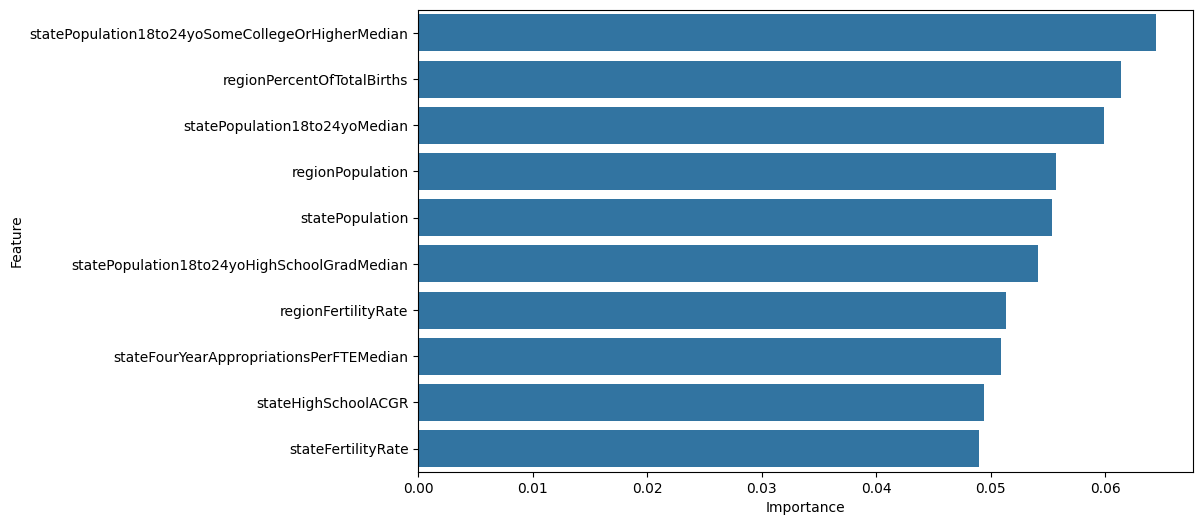

In [16]:
def permutation_importance_kmeans(X, kmeans, n_repeats=5):
    baseline_inertia = kmeans.inertia_
    feature_importance = np.zeros(X.shape[1])
    for feature in range(X.shape[1]):
        X_permuted = X.copy()
        for _ in range(n_repeats):
            np.random.shuffle(X_permuted[:, feature])
            kmeans_permuted = KMeans(n_clusters=optimal_k, random_state=rs).fit(X_permuted)
            feature_importance[feature] += (kmeans_permuted.inertia_ - baseline_inertia) / n_repeats
    return feature_importance / feature_importance.sum()

global_importance = permutation_importance_kmeans(X, kmeans)
global_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': global_importance})
global_importance_df = global_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=global_importance_df.head(10))
plt.show()

In [17]:
centroids = kmeans.cluster_centers_
college_explanations = []
for i in range(X.shape[0]):
    cluster = kmeans_labels[i]
    distances = np.abs(X[i] - centroids[cluster])
    contributions = distances / distances.sum()  # Normalize to get relative impact
    top_features_idx = np.argsort(contributions)[::-1][:5]
    top_features = feature_names[top_features_idx]
    top_contributions = contributions[top_features_idx]
    college_explanations.append({
        'name': labels['name'].iloc[i],
        'cluster': cluster,
        'top_feature_1': top_features[0],
        'impact_1': top_contributions[0],
        'top_feature_2': top_features[1],
        'impact_2': top_contributions[1],
        'top_feature_3': top_features[2],
        'impact_3': top_contributions[2],
        'top_feature_4': top_features[3],
        'impact_4': top_contributions[3],
        'top_feature_5': top_features[4],
        'impact_5': top_contributions[4]
    })

explanations_df = pd.DataFrame(college_explanations)
explanations_df

,name,cluster,top_feature_1,impact_1,top_feature_2,impact_2,top_feature_3,impact_3,top_feature_4,impact_4,top_feature_5,impact_5
0,Alderson Broaddus University,20,stateBirthRate,0.098175,locationType_Rural,0.090443,stateTwoYearStudentShareMedian,0.083411,stateTwoYearNetTuitionRevenuePerFTEMedian,0.074161,stateFertilityRate,0.047847
1,Alliance University (Formerly Nyack College),19,locationTypeKind_Small,0.135613,carnegieProgram_Larger Programs,0.135613,locationTypeKind_Large,0.135613,hasReligionAffiliation_True,0.135613,carnegieAward_Master's Colleges & Universities,0.135613
2,Ancilla College,15,stateUnemploymentRate,0.072987,locationType_Rural,0.058757,carnegieProgram_Mixed Transfer/Career & Techni...,0.058757,stateHighSchoolACGR,0.047380,carnegieProgram_Diverse Fields,0.044067
3,Becker College,10,carnegieProgram_Diverse Fields,0.134064,locationType_Suburb,0.134064,locationTypeKind_Large,0.134064,locationTypeKind_Midsize,0.134064,isMerged_FALSE,0.067032
4,Bloomfield College,6,statePerCapitaPersonalIncomeMedian,0.070838,stateFourYearStudentShareMedian,0.061280,stateFourYearAppropriationsPerFTEMedian,0.058780,stateUnemploymentRate,0.058500,carnegieAward_Baccalaureate Colleges,0.052327
...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,10,carnegieProgram_Small Programs,0.138732,carnegieAward_Baccalaureate Colleges,0.138732,hasReligionAffiliation_True,0.138732,carnegieAward_Master's Colleges & Universities,0.138732,carnegieProgram_Diverse Fields,0.069366
61,Cox College,1,locationTypeKind_Midsize,0.076864,carnegieProgram_Other Health Professions Schools,0.076864,hasReligionAffiliation_True,0.076864,locationType_Suburb,0.057648,isMerged_TRUE,0.057648
62,University of Wisconsin–Platteville Richland,14,totalEnrollment,0.164705,carnegieProgram_Larger Programs,0.113665,locationType_Town,0.094720,carnegieAward_Master's Colleges & Universities,0.094720,level_4-year,0.075776
63,Maryland University of Integrative Health,16,stateTwoYearAppropriationsPerFTEMedian,0.098268,stateHighSchoolACGR,0.067024,isMerged_TRUE,0.055412,hasUndergraduate_True,0.055412,level_graduate school,0.055412


In [18]:
for cluster in range(optimal_k):
    cluster_explanations = explanations_df[explanations_df['cluster'] == cluster]
    feature_counts = {}
    for i in range(1, 6):
        col = f'top_feature_{i}'
        for feature in cluster_explanations[col]:
            feature_counts[feature] = feature_counts.get(feature, 0) + 1
    feature_counts_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['Count'])
    feature_counts_df = feature_counts_df.sort_values('Count', ascending=False).head(5)
    print(f"\nCluster {cluster} Top Features by Frequency in Explanations:")
    print(feature_counts_df)


Cluster 0 Top Features by Frequency in Explanations:
                                                Count
hasSpecialDemographic_True                          2
locationTypeKind_Large                              2
hasReligionAffiliation_True                         2
locationType_Town                                   2
carnegieAward_Master's Colleges & Universities      1

Cluster 1 Top Features by Frequency in Explanations:
                                        Count
isMerged_TRUE                               3
stateTwoYearAppropriationsPerFTEMedian      2
locationTypeKind_Large                      2
carnegieAward_Special Focus Four-Year       2
stateTwoYearStudentShareMedian              2

Cluster 2 Top Features by Frequency in Explanations:
                                                Count
hasReligionAffiliation_True                         4
isMerged_TRUE                                       4
isMerged_FALSE                                      3
carnegieProgram_Small 

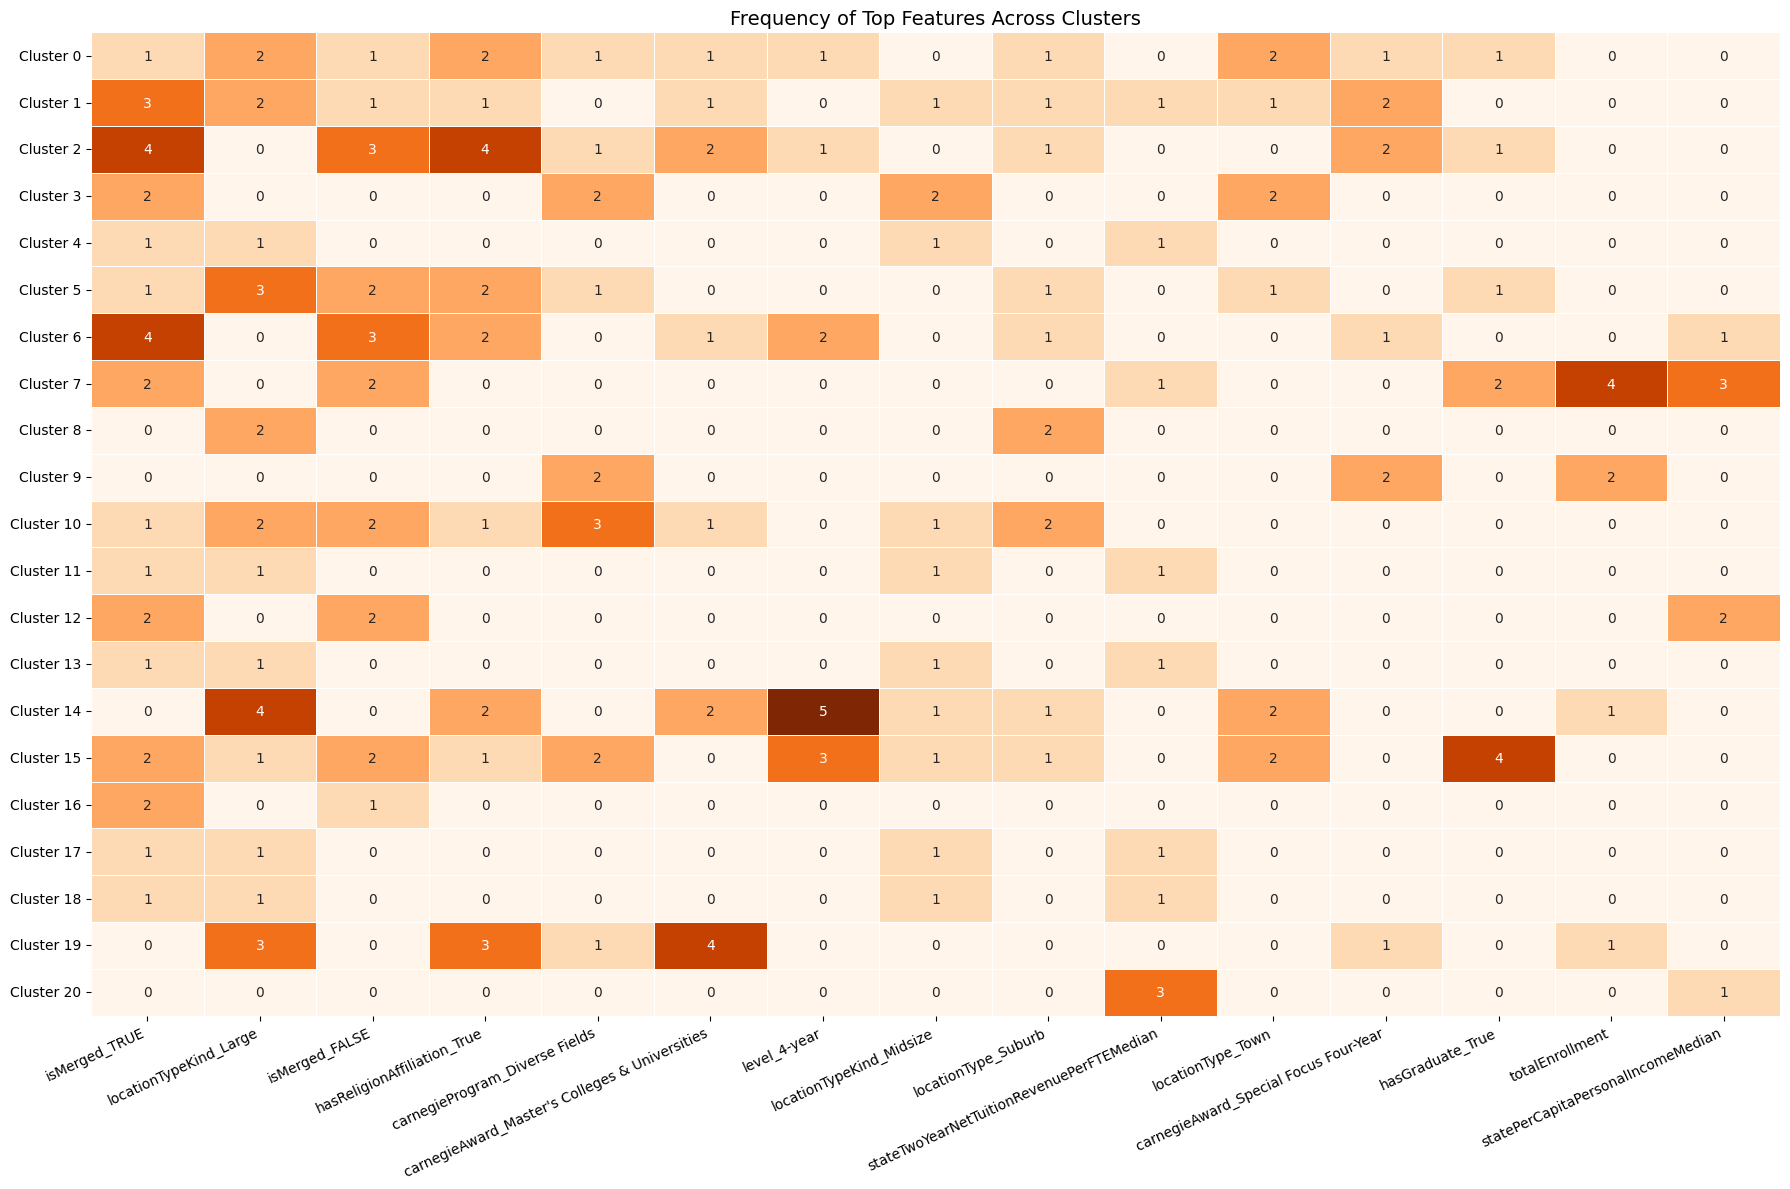

In [19]:
feature_freq_df = pd.DataFrame()

for cluster in range(optimal_k):
    cluster_explanations = explanations_df[explanations_df['cluster'] == cluster]
    feature_counts = {}
    for i in range(1, 6):
        col = f'top_feature_{i}'
        for feature in cluster_explanations[col]:
            feature_counts[feature] = feature_counts.get(feature, 0) + 1
    
    feature_counts_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=[f'Cluster {cluster}'])
    feature_freq_df = pd.concat([feature_freq_df, feature_counts_df], axis=1)

feature_freq_df = feature_freq_df.fillna(0)

top_features = feature_freq_df.sum(axis=1).sort_values(ascending=False).head(15).index

plt.figure(figsize=(18, 12))
sns.heatmap(feature_freq_df.loc[top_features].T, cmap='Oranges', annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'Frequency'}, cbar=False)
plt.title('Frequency of Top Features Across Clusters', fontsize=14)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [20]:
shap.initjs()
explainer = shap.KernelExplainer(kmeans.predict, X)
shap_values = explainer.shap_values(X)

100%|██████████| 65/65 [00:12<00:00,  5.02it/s]


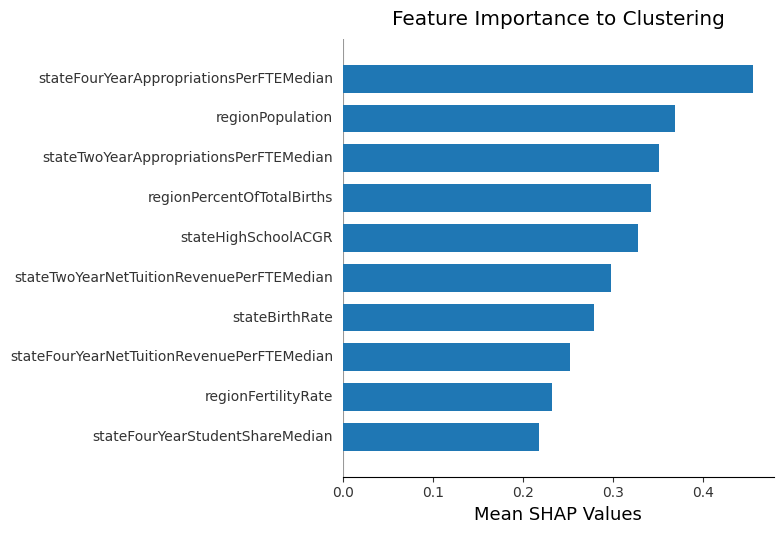

In [21]:
plt.figure(figsize=(10, 8))

plt.rcParams.update({'font.size': 12})
plt.title('Feature Importance to Clustering', pad=10)

shap.summary_plot(
    shap_values,
    X,
    feature_names=feature_names,
    plot_type='bar',
    max_display=10,
    show=False,
    color='tab:blue'
)
ax = plt.gca()

ax.set_xlabel('Mean SHAP Values')

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.yticks(ha='right', fontsize=10, va='center', rotation_mode='anchor')
plt.tight_layout()
plt.show()

In [96]:
def analyze_cluster(cluster_id, data, num_feats=5):
    cluster_indices = np.where(kmeans_labels == cluster_id)[0]
    
    if len(cluster_indices) == 0:
        return "Cluster data not available"
    cluster_shap_values = np.abs(shap_values[cluster_indices])
    
    mean_shap_values = np.mean(cluster_shap_values, axis=0)
    
    feature_importance = {feature: value for feature, value in zip(feature_names, mean_shap_values)}
    
    significant_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
    
    return dict(significant_features[:num_feats])

results = {}
for cluster_id in range(optimal_k):
    results[cluster_id] = analyze_cluster(cluster_id, shap_values)

for cluster_id, features in results.items():
    print(f"Cluster {cluster_id} Significant Features:")
    if isinstance(features, dict):
        for feature, score in features.items():
            print(f"  {feature}: {score:.3f}")
    else:
        print(f"    {features}")

Cluster 0 Significant Features:
  stateFourYearAppropriationsPerFTEMedian: 2.913
  stateTwoYearAppropriationsPerFTEMedian: 1.562
  stateTwoYearNetTuitionRevenuePerFTEMedian: 0.778
  stateFourYearStudentShareMedian: 0.665
  regionBirthRate: 0.526
Cluster 1 Significant Features:
  stateBirthRate: 1.081
  stateFertilityRate: 1.011
  stateHighSchoolACGR: 0.958
  regionPopulation: 0.887
  regionPercentOfTotalBirths: 0.802
Cluster 2 Significant Features:
  statePopulation18to24yoHighSchoolGradMedian: 0.890
  statePopulation25yoAndOverSomeCollegeOrHigherMedian: 0.835
  statePopulation: 0.809
  statePercentOfTotalBirths: 0.691
  statePopulation18to24yoSomeCollegeOrHigherMedian: 0.650
Cluster 3 Significant Features:
  stateHighSchoolACGR: 2.451
  stateFourYearNetTuitionRevenuePerFTEMedian: 1.072
  stateTwoYearNetTuitionRevenuePerFTEMedian: 0.764
  stateUnemploymentRate: 0.387
  stateTwoYearAppropriationsPerFTEMedian: 0.331
Cluster 4 Significant Features:
  endowmentMedian: 7.515
  totalEnrollme


Cluster 14 Significant Features:
  stateTwoYearStudentShareMedian: 0.807
  stateFourYearAppropriationsPerFTEMedian: 0.710
  stateTwoYearAppropriationsPerFTEMedian: 0.667
  stateTwoYearNetTuitionRevenuePerFTEMedian: 0.603
  stateBirthRate: 0.448


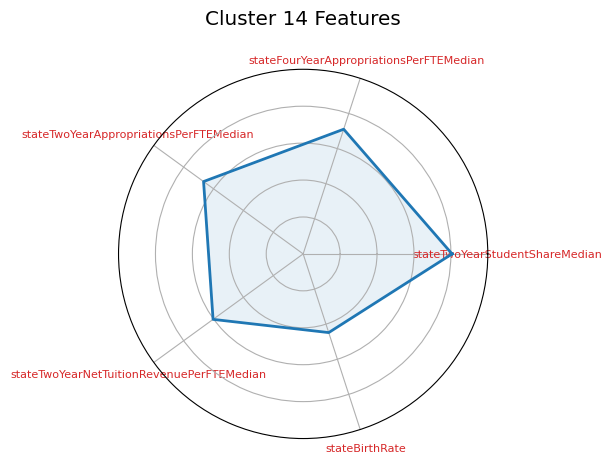

In [105]:
def plot_cluster_spider(cluster_id, feature_dict):
    N = len(feature_dict)
    
    max_value = max(feature_dict.values())
    if max_value > 1:
        normalized_values = {k: v / max_value for k, v in feature_dict.items()}
    else:
        normalized_values = feature_dict
    
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], list(normalized_values.keys()), color='tab:red', size=8)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["", "", "", ""])
    plt.ylim(0, 1)

    values = list(normalized_values.values())
    values += values[:1]

    ax.plot(angles, values, linewidth=2, linestyle='solid', color='tab:blue')
    ax.fill(angles, values, 'tab:blue', alpha=0.1)
    plt.title(f'Cluster {cluster_id} Features', y=1.1)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    results = {}
    for cluster_id in range(optimal_k):
        results[cluster_id] = analyze_cluster(cluster_id, shap_values)

    cluster_id = 14

    print(f"\nCluster {cluster_id} Significant Features:")
    for feature, score in results[cluster_id].items():
        print(f"  {feature}: {score:.3f}")
    
    plot_cluster_spider(cluster_id, results[cluster_id])